In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

In [2]:
#coffea output file
f_sig = "../coffea/corrected_sig_2022/ERE_Xcleaned.coffea"  #with x clean and pT bounds ntuples

#Nested Dictionary:
sig_histo = util.load(f_sig) [0]

Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
[7.220e+02 8.880e+02 1.360e+03 1.254e+03 9.660e+02 7.620e+02 5.560e+02
 3.790e+02 2.640e+02 1.970e+02 1.240e+02 8.500e+01 6.300e+01 3.700e+01
 3.700e+01 2.100e+01 1.600e+01 7.000e+00 1.100e+01 7.000e+00 3.000e+00
 3.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00
 0.000e+00 0.000e+00 0.000e+00 2.000e+00 0.000e+00 1.000e+00 1.000e+00
 0.000e+00 0.000e+00 2.000e+00 0.000e+00 0.000e+00]
pT bins: [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5 30.5 31.5 32.5 33.5 34.5 35.5 36.5 37.5 38.5 39.5]


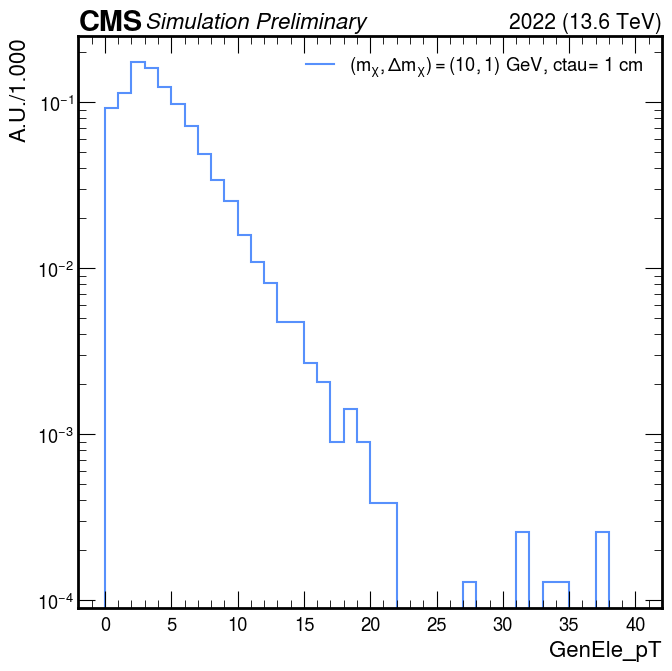

In [3]:
fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta=0.1
ctau=10

# Plot settings
plot_dict = {
    'variable': 'gen_ele_pt',
    'cut': 'cut0',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    'xlabel': "GenEle_pT",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}
# ptools.plot_signal_1D_lxy(
#         sig_histo, m1, delta, ctau,
#         plot_dict, style_dict,
#         match_type='L', passID=1
#     )

counts, edges = ptools.plot_signal_1D_match(sig_histo, m1, delta, ctau, plot_dict, style_dict,match_type='L', passID=1)
#signal points
# m1s = [10,20,30,50]

# ctaus = [10]

# results = [
#     ptools.plot_signal_1D_match(
#         sig_histo, m1, delta, ctau,
#         plot_dict, style_dict,
#         match_type='L', passID=1
#     )
#     # for ctau in ctaus
# ]

# counts, edges = zip(*results)

counts = np.array(counts)     # shape: (n_m1, n_bins)
edges  = np.array(edges)      # shape: (n_m1, n_edges)

print (counts)

mask = counts != 0

# bins_x = (edges[:, :-1] + edges[:, 1:])*(0.5)

bins_x = (edges[:-1] + edges[ 1:])*(0.5)

counts_nonzero_den = np.where(mask, counts, np.nan)
edges_nonzero_den  = np.where(mask, bins_x, np.nan)

print ("pT bins:", bins_x)

Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
[1.000e+00 2.840e+02 1.009e+03 1.028e+03 7.730e+02 5.570e+02 3.950e+02
 2.550e+02 1.790e+02 1.340e+02 8.100e+01 6.200e+01 4.400e+01 2.900e+01
 2.700e+01 1.600e+01 9.000e+00 4.000e+00 8.000e+00 4.000e+00 1.000e+00
 3.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00
 0.000e+00 0.000e+00 0.000e+00 2.000e+00 0.000e+00 1.000e+00 1.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]


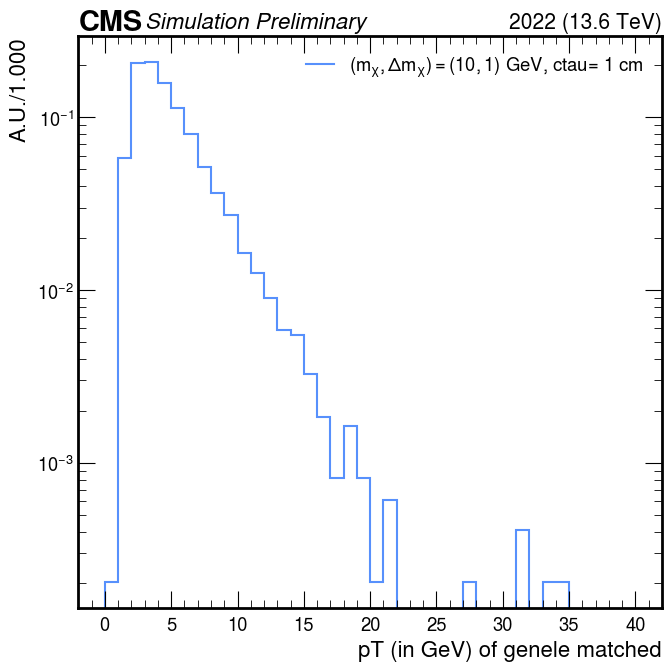

In [4]:
fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta = 0.1
ctau=10


plot_dict = {'variable': 'match_ele_gen_pt', 'cut': 'cut0', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT (in GeV) of genele matched",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}
# m1s = [10,20,30,50]
# deltas = [0.1]
# ctaus = [10]

counts, edges = ptools.plot_signal_1D_match(
        sig_histo, m1, delta, ctau,
        plot_dict, style_dict,
        match_type='L', passID=1
    )

# results = [
#     ptools.plot_signal_1D_match(
#         sig_histo, m1, delta, ctau,
#         plot_dict, style_dict,
#         match_type='L', passID=1
#     )
#     # for ctau in ctaus
# ]

# counts, edges = zip(*results)

counts_num = np.array(counts)     # shape: (n_m1, n_bins)
edges_num  = np.array(edges)      # shape: (n_m1, n_edges)

# bins_x_num = (edges_num[:, :-1] + edges_num[:, 1:])*(0.5)

bins_x_num = (edges_num[ :-1] + edges_num[ 1:])*(0.5)

print (counts_num)

#For low-pT algorithm:

#YES X clean, pt<1 GeV bound: 
# [0.000e+00 3.270e+02 1.140e+03 1.176e+03 9.950e+02 5.870e+02 3.750e+02
#  2.790e+02 1.650e+02 1.240e+02 9.700e+01 6.200e+01 4.200e+01 1.600e+01
#  2.400e+01 1.200e+01 1.200e+01 5.000e+00 2.000e+00 2.000e+00 1.000e+00
#  0.000e+00 2.000e+00 3.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
#  0.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00 1.000e+00 0.000e+00
#  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]


#NO X clean, no pT bound: Seeing more events after 5 GeV, low below 5 GeV

# [2.000e+00 3.470e+02 1.091e+03 1.076e+03 8.910e+02 6.460e+02 4.380e+02
#  3.370e+02 2.150e+02 1.590e+02 1.200e+02 7.800e+01 5.000e+01 1.800e+01
#  2.600e+01 1.500e+01 1.700e+01 7.000e+00 4.000e+00 2.000e+00 1.000e+00
#  0.000e+00 2.000e+00 3.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
#  2.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00 1.000e+00 0.000e+00
#  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]

#For GED algorithm

#Getting more events when there is xclean and pT bounds (beyond 4 GeV) 
#[  0.   1.   0.   2.  22. 147. 111. 100.  61.  46.  22.  15.   9.   4.
   # 2.   7.   1.   2.   0.   0.   0.   0.   0.   0.   0.   0.   0.   1.
   # 0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
#Getting less events when NO Xclean and low pt bounds:
#[  0.   1.   0.   1.  20. 114.  86.  73.  40.  32.  14.   7.   7.   4.
  # 1.   4.   0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   1.
   #0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]

In [7]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc


efficiency_R, unc_eff_R = eff_determine_unc(counts_num, counts_nonzero_den)

print (efficiency_R)
# print (unc_eff_R)


[0.00138504 0.31981982 0.74191176 0.81977671 0.80020704 0.73097113
 0.71043165 0.67282322 0.6780303  0.68020305 0.65322581 0.72941176
 0.6984127  0.78378378 0.72972973 0.76190476 0.5625     0.57142857
 0.72727273 0.57142857 0.33333333 1.                nan        nan
        nan        nan        nan 1.                nan        nan
        nan 1.                nan 1.         1.                nan
        nan 0.                nan        nan]


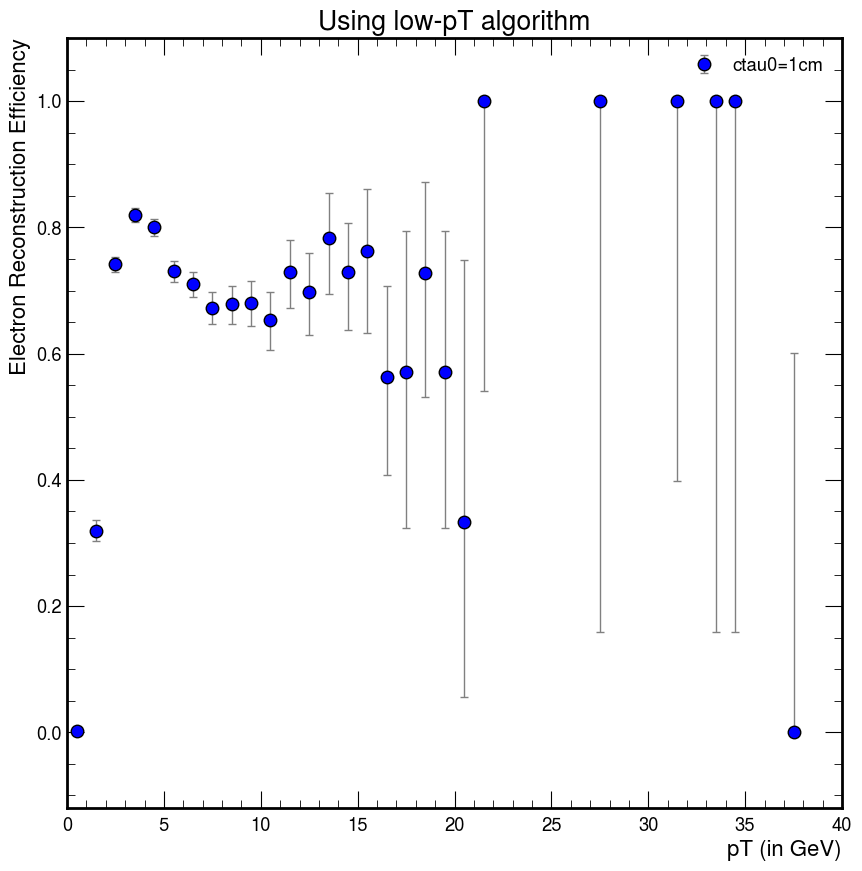

In [8]:
# plt.errorbar(
#     bins_x[0], efficiency_R[0],
#     yerr=unc_eff_R[:,0,:] ,fmt='o', markersize=9, markerfacecolor='blue', markeredgecolor='black',
#     ecolor='gray', elinewidth=1, capsize=3,
#     label='m1=10 GeV'  
# )

plt.errorbar(
    bins_x, efficiency_R,
    yerr=unc_eff_R ,fmt='o', markersize=9, markerfacecolor='blue', markeredgecolor='black',
    ecolor='gray', elinewidth=1, capsize=3,
    label='ctau0=1cm'  
)

# plt.errorbar(
#     bins_x[1], efficiency_R[1],
#     yerr=unc_eff_R[1,:,:] ,fmt='o', markersize=9, markerfacecolor='red', markeredgecolor='black',
#     ecolor='gray', elinewidth=1, capsize=3,
#     label='ctau0=10cm'  
# )


# plt.errorbar(
#     bins_x[1], efficiency_R[1],
#     yerr=unc_eff_R[:,1,:] ,fmt='o', markersize=9, markerfacecolor='red', markeredgecolor='black',
#     ecolor='gray', elinewidth=1, capsize=3,
#     label='m1=20 GeV'  
# )

# plt.errorbar(
#     bins_x[2], efficiency_R[2],
#     yerr=unc_eff_R[:,2,:] ,fmt='o', markersize=9, markerfacecolor='yellow', markeredgecolor='black',
#     ecolor='gray', elinewidth=1, capsize=3,
#     label='m1=30 GeV'  
# )


# plt.errorbar(
#     bins_x[3], efficiency_R[3],
#     yerr=unc_eff_R[:,3,:] ,fmt='o', markersize=9, markerfacecolor='purple', markeredgecolor='black',
#     ecolor='gray', elinewidth=1, capsize=3,
#     label='m1=50 GeV'  
# )


plt.ylim(-0.12,1.1)
plt.xlim(0,40)
plt.xlabel("pT (in GeV)")
plt.ylabel("Electron Reconstruction Efficiency")
plt.title("Using low-pT algorithm")
plt.legend(loc='upper right')
plt.savefig("pt510.png")